## For each buffer:
- for the preceeding year, (overwinter_start) find when the last hotspot was detected.
- for the proceeding year, (overwinter_1) find when the first hotspot was detected.
- for the end of processing year, (overwinter_1_end), find when the last hotspot was detected.
- for the proceeding year, (overwinter_2), find when the first hotspot was detected
- overwinter_start = 2023
- overwinter_1 = 2024
- overwinter_1_end = 2024 fall
- overwinter_2 = 2025

## Using the dates and location of each hotspot, calculate:
- time between two hotspots
- distances between two hotspots
- distance from buffer edge
- distance from previous years fire boundary
- when lightning was detected +/- 72 hrs
- when snow melted for each buffer.
- when snow onset for each buffer.


## Files:

**buffers:** geometery = original perimeter, buffer_wkt = buffer geom. Both in wkt must to transformed to geodataframe when read in.
- overwinter_start: data/processed_wildfire_buffers/perims_2023_clipped_buffers.parquet
- overwinter_1 : data/processed_wildfire_buffers/perims_2024_clipped_buffers.parquet
- overwinter_2 : data/processed_wildfire_buffers/perims_2025_clipped_buffers.parquet

**hotspots:**
= 2023-2024



## workflow:
Look at 2024 hotspots, and 2023 buffer. If a hotspot occurs in a 2023 buffer, find the day of the buffer. Return a dataframe multiple rows for each and hotspot overlap, have column for hotspot geometry or ID, and date. Keep all columns from perimeter.

In [2]:
import sys
sys.path.insert(0, "../src")

import geopandas as gpd
import pandas as pd
from find_hotspots_in_buffer import find_hotspots_in_buffers

# Analysis to look for overwinter fires based on hotspots and buffers. 

In [6]:
# read in hotspots
hotspots = gpd.read_file("../data/processed_hotspots/hotspots_clipped_all.shp")
hotspots.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,source,year,geometry
0,56.68786,-121.34752,322.47,0.51,0.41,2023/11/22 00:00:00,1053,N20,VIIRS,n,2,241.21,3.45,N,0.0,J1V-C2,2023,POINT (1284342.291 1308954.728)
1,56.76530,-121.34372,326.79,0.56,0.43,2024/02/23 00:00:00,2001,N20,VIIRS,n,2,282.72,28.14,D,0.0,J1V-C2,2024,POINT (1284006.321 1317591.281)
2,56.76736,-121.33795,328.85,0.56,0.43,2024/02/23 00:00:00,2001,N20,VIIRS,n,2,281.22,18.88,D,0.0,J1V-C2,2024,POINT (1284342.624 1317843.774)
3,56.77076,-121.34865,336.76,0.48,0.65,2024/02/17 00:00:00,2154,N20,VIIRS,n,2,277.97,19.53,D,0.0,J1V-C2,2024,POINT (1283666.056 1318179.355)
4,56.80400,-121.30665,340.56,0.47,0.48,2024/02/13 00:00:00,1948,N20,VIIRS,n,2,270.34,8.34,D,0.0,J1V-C2,2024,POINT (1285978.039 1322048.708)


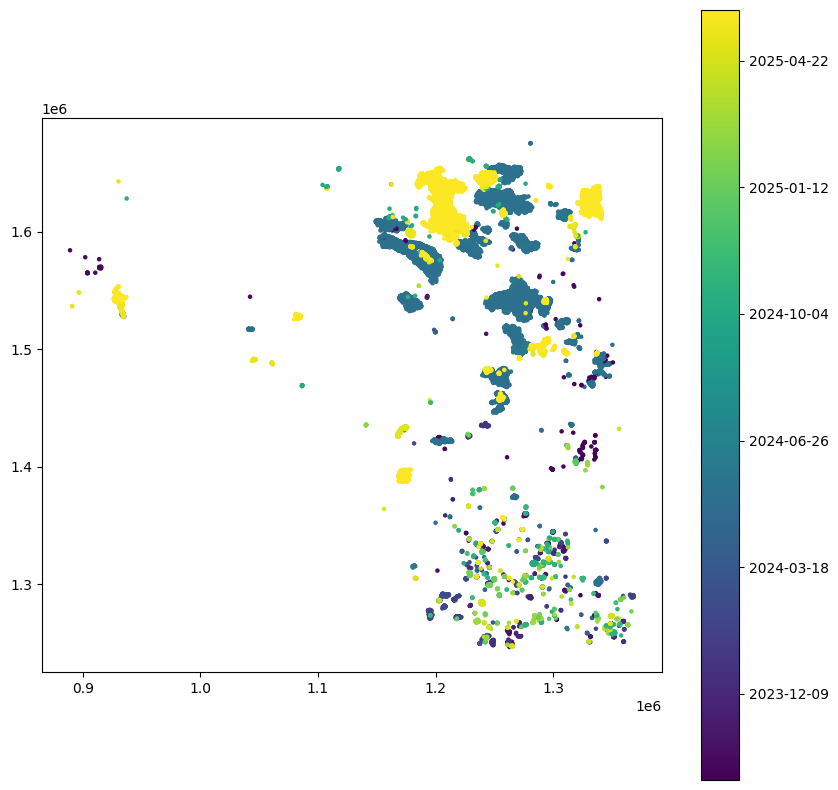

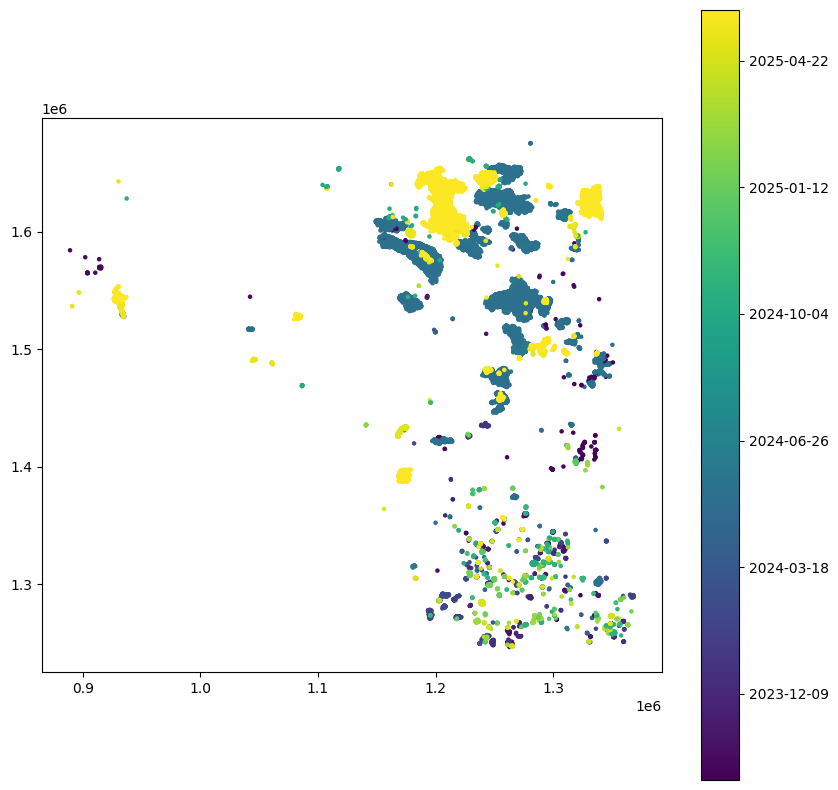

In [7]:
# Quick plot of hotspots coloured by acquisition date (safe for Matplotlib)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
# ensure datetime dtype and create numeric date for colormapping
hotspots['ACQ_DATE'] = pd.to_datetime(hotspots['ACQ_DATE'])
hotspots['date_num'] = hotspots['ACQ_DATE'].map(mdates.date2num)
fig, ax = plt.subplots(figsize=(10, 10))
col = hotspots.plot(column='date_num', ax=ax, legend=True, cmap='viridis', markersize=5)
# format colorbar ticks back to readable dates
cax = fig.axes[-1]
def _num2date(x, pos):
    return mdates.num2date(x).strftime('%Y-%m-%d')
cax.yaxis.set_major_formatter(mticker.FuncFormatter(_num2date))
fig

Get date column for hotspots

In [8]:
hotspots ['date']= pd.to_datetime(hotspots ['ACQ_DATE'])
hotspots ['year'] = hotspots ['date'].dt.year
hotspots ['month'] = hotspots ['date'].dt.month
hotspots ['day'] = hotspots ['date'].dt.day
hotspots.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,...,FRP,DAYNIGHT,TYPE,source,year,geometry,date_num,date,month,day
0,56.68786,-121.34752,322.47,0.51,0.41,2023-11-22,1053,N20,VIIRS,n,...,3.45,N,0.0,J1V-C2,2023,POINT (1284342.291 1308954.728),19683.0,2023-11-22,11,22
1,56.76530,-121.34372,326.79,0.56,0.43,2024-02-23,2001,N20,VIIRS,n,...,28.14,D,0.0,J1V-C2,2024,POINT (1284006.321 1317591.281),19776.0,2024-02-23,2,23
2,56.76736,-121.33795,328.85,0.56,0.43,2024-02-23,2001,N20,VIIRS,n,...,18.88,D,0.0,J1V-C2,2024,POINT (1284342.624 1317843.774),19776.0,2024-02-23,2,23
3,56.77076,-121.34865,336.76,0.48,0.65,2024-02-17,2154,N20,VIIRS,n,...,19.53,D,0.0,J1V-C2,2024,POINT (1283666.056 1318179.355),19770.0,2024-02-17,2,17
4,56.80400,-121.30665,340.56,0.47,0.48,2024-02-13,1948,N20,VIIRS,n,...,8.34,D,0.0,J1V-C2,2024,POINT (1285978.039 1322048.708),19766.0,2024-02-13,2,13


Only look at overwinter months

In [9]:
overwinter_months = [9, 10, 11, 12, 1, 2, 3, 4, 5, 6]
hs_offseason = hotspots[hotspots['date'].dt.month.isin(overwinter_months)]
hs_offseason.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,...,FRP,DAYNIGHT,TYPE,source,year,geometry,date_num,date,month,day
0,56.68786,-121.34752,322.47,0.51,0.41,2023-11-22,1053,N20,VIIRS,n,...,3.45,N,0.0,J1V-C2,2023,POINT (1284342.291 1308954.728),19683.0,2023-11-22,11,22
1,56.76530,-121.34372,326.79,0.56,0.43,2024-02-23,2001,N20,VIIRS,n,...,28.14,D,0.0,J1V-C2,2024,POINT (1284006.321 1317591.281),19776.0,2024-02-23,2,23
2,56.76736,-121.33795,328.85,0.56,0.43,2024-02-23,2001,N20,VIIRS,n,...,18.88,D,0.0,J1V-C2,2024,POINT (1284342.624 1317843.774),19776.0,2024-02-23,2,23
3,56.77076,-121.34865,336.76,0.48,0.65,2024-02-17,2154,N20,VIIRS,n,...,19.53,D,0.0,J1V-C2,2024,POINT (1283666.056 1318179.355),19770.0,2024-02-17,2,17
4,56.80400,-121.30665,340.56,0.47,0.48,2024-02-13,1948,N20,VIIRS,n,...,8.34,D,0.0,J1V-C2,2024,POINT (1285978.039 1322048.708),19766.0,2024-02-13,2,13


Normalizing confidence levels.. Modis uses values 0-100, while VIIRS uses values l,m,h

In [10]:
def normalize_confidence(val):
    # VIIRS categorical
    if val in ('h', 'high'):
        return 'high'
    elif val in ('n', 'nominal'):
        return 'medium'
    elif val in ('l', 'low'):
        return 'low'
    # MODIS numeric (stored as string)
    try:
        v = int(val)
        if v >= 80:
            return 'high'
        elif v >= 50:
            return 'medium'
        else:
            return 'low'
    except (ValueError, TypeError):
        return 'unknown'

hs_offseason['confidence_class'] = hs_offseason['CONFIDENCE'].apply(normalize_confidence)

# Sanity check
print(hs_offseason['confidence_class'].value_counts())

confidence_class
medium    69410
high       8624
low        6586
Name: count, dtype: int64


Filter to only medium and high confidence

In [11]:
hs_offseason = hs_offseason[hs_offseason['confidence_class'].isin(['medium', 'high'])].copy()


In [12]:
hs_offseason.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 78034 entries, 0 to 84619
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   LATITUDE          78034 non-null  float64       
 1   LONGITUDE         78034 non-null  float64       
 2   BRIGHTNESS        78034 non-null  float64       
 3   SCAN              78034 non-null  float64       
 4   TRACK             78034 non-null  float64       
 5   ACQ_DATE          78034 non-null  datetime64[us]
 6   ACQ_TIME          78034 non-null  str           
 7   SATELLITE         78034 non-null  str           
 8   INSTRUMENT        78034 non-null  str           
 9   CONFIDENCE        78034 non-null  str           
 10  VERSION           78034 non-null  str           
 11  BRIGHT_T31        78034 non-null  float64       
 12  FRP               78034 non-null  float64       
 13  DAYNIGHT          78034 non-null  str           
 14  TYPE              5

Read in the buffers which will be used to search for hotspots in 2024

In [13]:
# read in buffers
buffers = pd.read_parquet("../data/processed_wildfire_buffers/perims_2023_clipped_buffers.parquet")
buffers.head()

,FIRE_NO,VERSION_NO,FIRE_YEAR,FIRE_CAUSE,FIRELABEL,SIZE_HA,SOURCE,TRACK_DATE,LOAD_DATE,FIRE_DATE,METHOD,FCODE,SHAPE,OBJECTID,AREA_SQM,FEAT_LEN,geometry,crs,buffer_wkt
23838,G80561,2.023060e+09,2023,Person,2023-G80561,3.6,2023 ROLLOVER,20230602,20230604,20230601,Non-corrected ground GPS,JA70003000,NaN,3180746.0,3.643531e+04,1090.5077,"POLYGON ((1294972.9061 1264534.2386, 1294970.9...",EPSG:3005,"POLYGON ((1293954.863103 1264476.491498, 12939..."
24119,G80052,2.023043e+09,2023,Person,2023-G80052,2.0,2023 ROLLOVER,20230428,20230428,20230416,Hand sketch of any type,JA70003000,NaN,3180728.0,2.009831e+04,582.3461,"POLYGON ((1301948.1719 1266513.373, 1301952.02...",EPSG:3005,"POLYGON ((1301066.994503 1266986.158781, 13011..."
24147,G80120,2.023043e+09,2023,Person,2023-G80120,1.5,2023 ROLLOVER,20230429,20230502,20230428,Non-corrected ground GPS,JA70003000,NaN,3180732.0,1.496113e+04,587.0283,"POLYGON ((1326551.0284 1266663.697, 1326573.46...",EPSG:3005,"POLYGON ((1325710.562105 1266038.638469, 13256..."
23813,G80190,2.023050e+09,2023,Person,2023-G80190,89.0,2023 ROLLOVER,20230504,20230510,20230503,Non-corrected ground GPS,JA70003000,NaN,3180739.0,8.900510e+05,7428.3175,"POLYGON ((1302268.9373 1271420.9943, 1302276.0...",EPSG:3005,"POLYGON ((1301068.371268 1271196.503269, 13010..."
23814,G80220,2.023051e+09,2023,Person,2023-G80220,6422.2,2023 ROLLOVER,20230513,20230513,20230501,Non-corrected airborne GPS,JA70003000,NaN,3180740.0,6.422172e+07,51424.1780,"POLYGON ((1366672.4458 1275195.5936, 1366700.3...",EPSG:3005,"POLYGON ((1359075.017904 1273224.417566, 13590..."


In [14]:
buffers_2023 = gpd.GeoDataFrame(buffers, geometry=gpd.GeoSeries.from_wkt(buffers["buffer_wkt"]), crs="EPSG:3005")

In [4]:
perimeters_2023 = gpd.read_file("../data/processed_fire_perimeters/perims_2023_clipped_3005.geojson")

In [15]:
perimeters_2024 = gpd.read_file("../data/processed_fire_perimeters/perims_2024_clipped_3005.geojson")


2024-2025

In [16]:
buffers_2024 = pd.read_parquet("../data/processed_wildfire_buffers/perims_2024_clipped_buffers.parquet")
# make geodataframe with geometry column from WKT
buffers_2024 = gpd.GeoDataFrame(buffers_2024, geometry=gpd.GeoSeries.from_wkt(buffers_2024["buffer_wkt"]), crs="EPSG:3005")

In [17]:
perimeters_2025 = gpd.read_file("../data/processed_fire_perimeters/perims_2025_clipped_3005.geojson")

# DF per fire
- Because first hotspot may not be closest to the last, it is important to look at each fire individually. Where are the two closest hotspots for each season?

In [18]:
hs_2023_all = hs_offseason[hs_offseason['year'] == 2023].copy()
hs_2024_all = hs_offseason[hs_offseason['year'] == 2024].copy()
hs_2025_all = hs_offseason[hs_offseason['year'] == 2025].copy()


In [19]:
hs_offseason.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 78034 entries, 0 to 84619
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   LATITUDE          78034 non-null  float64       
 1   LONGITUDE         78034 non-null  float64       
 2   BRIGHTNESS        78034 non-null  float64       
 3   SCAN              78034 non-null  float64       
 4   TRACK             78034 non-null  float64       
 5   ACQ_DATE          78034 non-null  datetime64[us]
 6   ACQ_TIME          78034 non-null  str           
 7   SATELLITE         78034 non-null  str           
 8   INSTRUMENT        78034 non-null  str           
 9   CONFIDENCE        78034 non-null  str           
 10  VERSION           78034 non-null  str           
 11  BRIGHT_T31        78034 non-null  float64       
 12  FRP               78034 non-null  float64       
 13  DAYNIGHT          78034 non-null  str           
 14  TYPE              5

In [20]:
# ── W1: 2023 hotspots WITHIN 2023 perimeter ──────────────────────────────
hs_2023_in_perim = gpd.sjoin(
    hs_2023_all,
    perimeters_2023[['FIRE_NO', 'geometry']],
    how='inner',
    predicate='within'
).rename(columns={'FIRE_NO': 'FIRE_NO_2023'})
hs_2023_in_perim['hs_type'] = 'within_perimeter'
hs_2023_in_perim['year_season'] = '2023'

# ── W1: 2024 hotspots WITHIN 2023 buffer ─────────────────────────────────
hs_2024_in_buf = gpd.sjoin(
    hs_2024_all,             # already filtered to Oct 2023 – May 2024
    buffers_2023[['FIRE_NO', 'geometry']],
    how='inner',
    predicate='within'
).rename(columns={'FIRE_NO': 'FIRE_NO_2023'})
hs_2024_in_buf['hs_type'] = 'within_buffer'
hs_2024_in_buf['year_season'] = '2024_winter'

# ── W2: 2024 hotspots WITHIN 2024 perimeter ──────────────────────────────
hs_2024_in_perim = gpd.sjoin(
    hs_2024_all,
    perimeters_2024[['FIRE_NO', 'geometry']],
    how='inner',
    predicate='within'
).rename(columns={'FIRE_NO': 'FIRE_NO_2024'})
hs_2024_in_perim['hs_type'] = 'within_perimeter'
hs_2024_in_perim['year_season'] = '2024'

# ── W2: 2025 hotspots WITHIN 2024 buffer ─────────────────────────────────
hs_2025_in_buf = gpd.sjoin(
    hs_2025_all,             # already filtered to Oct 2024 – May 2025
    buffers_2024[['FIRE_NO', 'geometry']],
    how='inner',
    predicate='within'
).rename(columns={'FIRE_NO': 'FIRE_NO_2024'})
hs_2025_in_buf['hs_type'] = 'within_buffer'
hs_2025_in_buf['year_season'] = '2025_winter'

In [21]:
# --- Fires that have BOTH 2023 perimeter hotspots AND 2024 buffer hotspots ---
w1_perim_fires = set(hs_2023_in_perim['FIRE_NO_2023'].unique())
w1_buf_fires   = set(hs_2024_in_buf['FIRE_NO_2023'].unique())
w1_confirmed   = w1_perim_fires & w1_buf_fires
print(f"W1 confirmed fires: {len(w1_confirmed)}")

# --- Fires that have BOTH 2024 perimeter hotspots AND 2025 buffer hotspots ---
w2_perim_fires = set(hs_2024_in_perim['FIRE_NO_2024'].unique())
w2_buf_fires   = set(hs_2025_in_buf['FIRE_NO_2024'].unique())
w2_confirmed   = w2_perim_fires & w2_buf_fires
print(f"W2 confirmed fires: {len(w2_confirmed)}")

# --- Build lineage: link FIRE_NO_2023 → FIRE_NO_2024 via spatial join ---
# Which 2023 fires reactivated into which 2024 fires?
lineage = gpd.sjoin(
    perimeters_2023[perimeters_2023['FIRE_NO'].isin(w1_confirmed)]
        .rename(columns={'FIRE_NO': 'FIRE_NO_2023'})[['FIRE_NO_2023', 'geometry']],
    perimeters_2024[perimeters_2024['FIRE_NO'].isin(w2_confirmed)]
        .rename(columns={'FIRE_NO': 'FIRE_NO_2024'})[['FIRE_NO_2024', 'geometry']],
    how='inner',
    predicate='intersects'
)[['FIRE_NO_2023', 'FIRE_NO_2024']].drop_duplicates()

print(f"Lineage links found: {len(lineage)}")
print(lineage.to_string())

# --- Link FIRE_NO_2024 → FIRE_NO_2025 via spatial join ---
lineage_2025 = gpd.sjoin(
    perimeters_2024[perimeters_2024['FIRE_NO'].isin(w2_confirmed)]
        .rename(columns={'FIRE_NO': 'FIRE_NO_2024'})[['FIRE_NO_2024', 'geometry']],
    perimeters_2025
        .rename(columns={'FIRE_NO': 'FIRE_NO_2025'})[['FIRE_NO_2025', 'geometry']],
    how='inner',
    predicate='intersects'
)[['FIRE_NO_2024', 'FIRE_NO_2025']].drop_duplicates()

print(f"2024→2025 lineage links: {len(lineage_2025)}")

# --- Combine into two_winter_confirmed ---
two_winter_confirmed = (
    lineage
    .merge(lineage_2025, on='FIRE_NO_2024', how='inner')
)

print(f"\ntwo_winter_confirmed recreated: {len(two_winter_confirmed)} fires")
print(two_winter_confirmed[['FIRE_NO_2023', 'FIRE_NO_2024', 'FIRE_NO_2025']].to_string())

W1 confirmed fires: 8
W2 confirmed fires: 7
Lineage links found: 5
   FIRE_NO_2023 FIRE_NO_2024
32       G90273       G80270
52       G90628       G80286
52       G90628       G90228
53       G92498       G90228
69       G92940       G90228
2024→2025 lineage links: 25

two_winter_confirmed recreated: 59 fires
   FIRE_NO_2023 FIRE_NO_2024 FIRE_NO_2025
0        G90273       G80270       G80396
1        G90273       G80270       G90425
2        G90273       G80270       G80418
3        G90273       G80270       G90397
4        G90628       G80286       G90428
5        G90628       G90228       G80402
6        G90628       G90228       G90461
7        G90628       G90228       G90507
8        G90628       G90228       G90243
9        G90628       G90228       G90338
10       G90628       G90228       G90715
11       G90628       G90228       G90714
12       G90628       G90228       G80426
13       G90628       G90228       G80403
14       G90628       G90228       G80427
15       G90628  

build per-fire w1 and w2 dataframes

In [22]:
# Columns to keep
cols = ['LATITUDE', 'LONGITUDE', 'date', 'ACQ_DATE', 'ACQ_TIME',
        'SATELLITE', 'FRP', 'BRIGHTNESS', 'confidence_class',
        'DAYNIGHT', 'source', 'hs_type', 'year_season', 'geometry']

w1_dict = {}
w2_dict = {}

for _, fire in two_winter_confirmed.iterrows():
    fn_2023 = fire['FIRE_NO_2023']
    fn_2024 = fire['FIRE_NO_2024']

    # ── W1: 2023 perimeter hotspots + 2024 buffer hotspots ───────────────
    w1_perim = hs_2023_in_perim[
        hs_2023_in_perim['FIRE_NO_2023'] == fn_2023
    ][cols].copy()

    w1_buf = hs_2024_in_buf[
        hs_2024_in_buf['FIRE_NO_2023'] == fn_2023
    ][cols].copy()

    w1 = pd.concat([w1_perim, w1_buf]).sort_values('date').reset_index(drop=True)
    w1['FIRE_NO_2023'] = fn_2023
    w1_dict[fn_2023] = w1

    # ── W2: 2024 perimeter hotspots + 2025 buffer hotspots ───────────────
    w2_perim = hs_2024_in_perim[
        hs_2024_in_perim['FIRE_NO_2024'] == fn_2024
    ][cols].copy()

    w2_buf = hs_2025_in_buf[
        hs_2025_in_buf['FIRE_NO_2024'] == fn_2024
    ][cols].copy()

    w2 = pd.concat([w2_perim, w2_buf]).sort_values('date').reset_index(drop=True)
    w2['FIRE_NO_2024'] = fn_2024
    w2_dict[fn_2023] = w2  # keyed by 2023 ID for consistent lookup

# Quick check
for fn in w1_dict.keys():
    w1 = w1_dict[fn]
    w2 = w2_dict[fn]
    print(f"{fn} | W1: {len(w1[w1['hs_type']=='within_perimeter'])} perim + "
          f"{len(w1[w1['hs_type']=='within_buffer'])} buffer | "
          f"W2: {len(w2[w2['hs_type']=='within_perimeter'])} perim + "
          f"{len(w2[w2['hs_type']=='within_buffer'])} buffer")

G90273 | W1: 3 perim + 111 buffer | W2: 3353 perim + 317 buffer
G90628 | W1: 25 perim + 275 buffer | W2: 20788 perim + 1571 buffer
G92498 | W1: 15 perim + 1125 buffer | W2: 20788 perim + 1571 buffer
G92940 | W1: 9 perim + 1038 buffer | W2: 20788 perim + 1571 buffer


check the number of hotspots in 2023 , why are these so many missing in perims?

In [23]:
hs_2023_all['date'].min(), hs_2023_all['date'].max()

(Timestamp('2023-10-02 00:00:00'), Timestamp('2023-12-31 00:00:00'))

In [24]:
# Add winter_year label before combining
for fn in w1_dict.keys():
    w1_dict[fn]['winter_year'] = 'W1_2023_2024'

for fn in w2_dict.keys():
    w2_dict[fn]['winter_year'] = 'W2_2024_2025'

# Combine all fires and both winters into one GeoDataFrame
all_winters = []

for fn in w1_dict.keys():
    w1 = w1_dict[fn].copy()
    w2 = w2_dict[fn].copy()

    # Make sure both have FIRE_NO_2023 for consistent linking
    w1['FIRE_NO_2023'] = fn
    w2['FIRE_NO_2023'] = fn  # already set but ensure consistency

    all_winters.append(w1)
    all_winters.append(w2)

full_df = gpd.GeoDataFrame(
    pd.concat(all_winters, ignore_index=True),
    crs='EPSG:3005'
)

# Reorder columns cleanly
col_order = ['FIRE_NO_2023', 'winter_year', 'hs_type', 'year_season',
             'date', 'ACQ_DATE', 'ACQ_TIME', 'SATELLITE', 'source',
             'FRP', 'BRIGHTNESS', 'confidence_class', 'DAYNIGHT',
             'LATITUDE', 'LONGITUDE', 'geometry']

full_df = full_df[col_order].sort_values(
    ['FIRE_NO_2023', 'winter_year', 'date']
).reset_index(drop=True)

print(f"Total rows: {len(full_df)}")
print(f"Fires: {full_df['FIRE_NO_2023'].nunique()}")
print(full_df.groupby(['FIRE_NO_2023', 'winter_year', 'hs_type']).size()
      .rename('n_hotspots').reset_index().to_string(index=False))

Total rows: 73348
Fires: 4
FIRE_NO_2023  winter_year          hs_type  n_hotspots
      G90273 W1_2023_2024    within_buffer         111
      G90273 W1_2023_2024 within_perimeter           3
      G90273 W2_2024_2025    within_buffer         317
      G90273 W2_2024_2025 within_perimeter        3353
      G90628 W1_2023_2024    within_buffer         275
      G90628 W1_2023_2024 within_perimeter          25
      G90628 W2_2024_2025    within_buffer        1571
      G90628 W2_2024_2025 within_perimeter       20788
      G92498 W1_2023_2024    within_buffer        1125
      G92498 W1_2023_2024 within_perimeter          15
      G92498 W2_2024_2025    within_buffer        1571
      G92498 W2_2024_2025 within_perimeter       20788
      G92940 W1_2023_2024    within_buffer        1038
      G92940 W1_2023_2024 within_perimeter           9
      G92940 W2_2024_2025    within_buffer        1571
      G92940 W2_2024_2025 within_perimeter       20788


In [25]:
# Add hotspot_year from the date column
full_df['hotspot_year'] = full_df['date'].dt.year

# Reorder columns cleanly
col_order = ['FIRE_NO_2023', 'winter_year', 'hs_type', 'year_season', 'hotspot_year',
             'date', 'ACQ_DATE', 'ACQ_TIME', 'SATELLITE', 'source',
             'FRP', 'BRIGHTNESS', 'confidence_class', 'DAYNIGHT',
             'LATITUDE', 'LONGITUDE', 'geometry']

full_df = full_df[col_order].sort_values(
    ['FIRE_NO_2023', 'winter_year', 'date']
).reset_index(drop=True)

# Sanity check — each winter_year should have expected hotspot_years
print(full_df.groupby(['winter_year', 'hs_type', 'hotspot_year']).size()
      .rename('n_hotspots').reset_index().to_string(index=False))

 winter_year          hs_type  hotspot_year  n_hotspots
W1_2023_2024    within_buffer          2024        2549
W1_2023_2024 within_perimeter          2023          52
W2_2024_2025    within_buffer          2025        5030
W2_2024_2025 within_perimeter          2024       65717


In [26]:
# Count 2023 perimeter hotspots per fire
hs_2023_counts = (
    full_df[full_df['hotspot_year'] == 2023]
    .groupby('FIRE_NO_2023')
    .size()
    .rename('n_2023_hotspots')
    .reset_index()
)

# Find fires with zero 2023 hotspots
fires_with_no_2023 = set(full_df['FIRE_NO_2023'].unique()) - set(hs_2023_counts['FIRE_NO_2023'])

print(f"Fires removed (no 2023 hotspots): {len(fires_with_no_2023)}")
print(fires_with_no_2023)

# Filter full_df to keep only fires that have at least 1 hotspot in 2023
full_df = full_df[~full_df['FIRE_NO_2023'].isin(fires_with_no_2023)].reset_index(drop=True)

print(f"\nFires remaining: {full_df['FIRE_NO_2023'].nunique()}")
print(f"Total rows remaining: {len(full_df)}")

Fires removed (no 2023 hotspots): 0
set()

Fires remaining: 4
Total rows remaining: 73348


Visualize the hotspots

In [78]:
from pathlib import Path
import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np

map_dir = Path("../results/fire_hotspot_maps")
map_dir.mkdir(exist_ok=True)

def plot_fire_hotspots(fire_no_2023):

    # --- Subset full_df for this fire ---
    fire_df = full_df[full_df['FIRE_NO_2023'] == fire_no_2023].copy()

    # --- Split by hotspot_year and hs_type ---
    hs_2023 = fire_df[
        (fire_df['hotspot_year'] == 2023) &
        (fire_df['hs_type'] == 'within_perimeter')
    ].to_crs(epsg=3857)

    hs_2024_buf = fire_df[
        (fire_df['hotspot_year'] == 2024) &
        (fire_df['hs_type'] == 'within_buffer')
    ].to_crs(epsg=3857)

    # --- Perimeters and buffer ---
    perim_2023 = perimeters_2023[
        perimeters_2023['FIRE_NO'] == fire_no_2023
    ].to_crs(epsg=3857)

    buf_2023 = buffers_2023[
        buffers_2023['FIRE_NO'] == fire_no_2023
    ].to_crs(epsg=3857)

    # --- Compute extent from all layers ---
    all_bounds = np.array([
        layer.total_bounds for layer in
        [perim_2023, buf_2023, hs_2023, hs_2024_buf]
        if not layer.empty
    ])
    pad = 3000
    minx = all_bounds[:, 0].min() - pad
    miny = all_bounds[:, 1].min() - pad
    maxx = all_bounds[:, 2].max() + pad
    maxy = all_bounds[:, 3].max() + pad

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(12, 10))

    # Fire perimeter — light red fill
    if not perim_2023.empty:
        perim_2023.plot(ax=ax, color='#ffcccc', edgecolor='#cc0000',
                        linewidth=1.2, alpha=0.6, label='2023 perimeter')

    # Buffer — blue outline only
    if not buf_2023.empty:
        buf_2023.plot(ax=ax, color='none', edgecolor='steelblue',
                      linewidth=1.5, linestyle='--', label='2023 buffer (1000m)')

    # 2023 hotspots — dark red
    if not hs_2023.empty:
        hs_2023.plot(ax=ax, color='darkred', markersize=15,
                     alpha=0.8, zorder=5,
                     label=f'2023 hotspots in perimeter (n={len(hs_2023)})')

    # 2024 winter hotspots in buffer — blue
    if not hs_2024_buf.empty:
        hs_2024_buf.plot(ax=ax, color='steelblue', markersize=15,
                         alpha=0.8, zorder=5,
                         label=f'2024 hotspots in buffer (n={len(hs_2024_buf)})')

    # Set extent
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    # Basemap
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom='auto')

    # Annotation
    stats_text = (
        f"FIRE_NO: {fire_no_2023}\n"
        f"─────────────────────\n"
        f"2023 hotspots (perimeter): {len(hs_2023)}\n"
        f"2024 hotspots (buffer):    {len(hs_2024_buf)}"
    )
    ax.text(0.02, 0.97, stats_text,
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85))

    ax.set_title(f'Overwintering Fire: {fire_no_2023} — W1 Hotspot Overview',
                 fontsize=13, fontweight='bold', pad=12)
    ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
    ax.set_axis_off()

    plt.tight_layout()
    fname = map_dir / f"{fire_no_2023}_w1_hotspots.png"
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.close()
    print(f"Saved: {fname}")


# --- Run for all remaining fires ---
for fn in full_df['FIRE_NO_2023'].unique():
    plot_fire_hotspots(fn)

print(f"\nDone — maps saved to '{map_dir}/'")

Saved: ../results/fire_hotspot_maps/G90273_w1_hotspots.png
Saved: ../results/fire_hotspot_maps/G90628_w1_hotspots.png
Saved: ../results/fire_hotspot_maps/G92498_w1_hotspots.png
Saved: ../results/fire_hotspot_maps/G92940_w1_hotspots.png

Done — maps saved to '../results/fire_hotspot_maps/'


In [79]:
def plot_fire_hotspots_combined(fire_no_2023):

    fire_row = two_winter_confirmed[
        two_winter_confirmed['FIRE_NO_2023'] == fire_no_2023
    ].iloc[0]
    fire_no_2024 = fire_row['FIRE_NO_2024']
    fire_no_2025 = fire_row['FIRE_NO_2025']

    fire_df = full_df[full_df['FIRE_NO_2023'] == fire_no_2023].copy()

    # --- W1 layers ---
    hs_2023 = fire_df[
        (fire_df['hotspot_year'] == 2023) &
        (fire_df['hs_type'] == 'within_perimeter')
    ].to_crs(epsg=3857)

    hs_2024_buf = fire_df[
        (fire_df['hotspot_year'] == 2024) &
        (fire_df['hs_type'] == 'within_buffer')
    ].to_crs(epsg=3857)

    perim_2023  = perimeters_2023[perimeters_2023['FIRE_NO'] == fire_no_2023].to_crs(epsg=3857)
    buf_2023    = buffers_2023[buffers_2023['FIRE_NO'] == fire_no_2023].to_crs(epsg=3857)

    # --- W2 layers ---
    hs_2024_perim = fire_df[
        (fire_df['hotspot_year'] == 2024) &
        (fire_df['hs_type'] == 'within_perimeter')
    ].to_crs(epsg=3857)

    hs_2025_buf = fire_df[
        (fire_df['hotspot_year'] == 2025) &
        (fire_df['hs_type'] == 'within_buffer')
    ].to_crs(epsg=3857)

    perim_2024  = perimeters_2024[perimeters_2024['FIRE_NO'] == fire_no_2024].to_crs(epsg=3857)
    buf_2024    = buffers_2024[buffers_2024['FIRE_NO'] == fire_no_2024].to_crs(epsg=3857)

    # --- Compute extent per panel independently ---
    def get_extent(layers, pad=3000):
        bounds = np.array([l.total_bounds for l in layers if not l.empty])
        if len(bounds) == 0:
            return None
        return (bounds[:, 0].min() - pad, bounds[:, 1].min() - pad,
                bounds[:, 2].max() + pad, bounds[:, 3].max() + pad)

    ext_w1 = get_extent([perim_2023, buf_2023, hs_2023, hs_2024_buf])
    ext_w2 = get_extent([perim_2024, buf_2024, hs_2024_perim, hs_2025_buf])

    # --- Figure with two panels ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

    # ── W1 panel (left) ───────────────────────────────────────────────────
    if not perim_2023.empty:
        perim_2023.plot(ax=ax1, color='#ffcccc', edgecolor='#cc0000',
                        linewidth=1.2, alpha=0.6, label='2023 perimeter')
    if not buf_2023.empty:
        buf_2023.plot(ax=ax1, color='none', edgecolor='steelblue',
                      linewidth=1.5, linestyle='--', label='2023 buffer (1000m)')
    if not hs_2023.empty:
        hs_2023.plot(ax=ax1, color='darkred', markersize=15, alpha=0.8,
                     zorder=5, label=f'2023 hotspots in perimeter (n={len(hs_2023)})')
    if not hs_2024_buf.empty:
        hs_2024_buf.plot(ax=ax1, color='steelblue', markersize=15, alpha=0.8,
                         zorder=5, label=f'2024 hotspots in buffer (n={len(hs_2024_buf)})')

    if ext_w1:
        ax1.set_xlim(ext_w1[0], ext_w1[2])
        ax1.set_ylim(ext_w1[1], ext_w1[3])

    ctx.add_basemap(ax1, source=ctx.providers.CartoDB.Positron, zoom='auto')

    ax1.text(0.02, 0.97,
             f"FIRE_NO 2023: {fire_no_2023}\n"
             f"─────────────────────\n"
             f"2023 hotspots (perimeter): {len(hs_2023)}\n"
             f"2024 hotspots (buffer):    {len(hs_2024_buf)}",
             transform=ax1.transAxes, fontsize=9, verticalalignment='top',
             fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85))

    ax1.set_title(f'W1: {fire_no_2023} → {fire_no_2024}\n(2023 perimeter + 2024 buffer hotspots)',
                  fontsize=11, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=8, framealpha=0.9)
    ax1.set_axis_off()

    # ── W2 panel (right) ──────────────────────────────────────────────────
    if not perim_2024.empty:
        perim_2024.plot(ax=ax2, color='#ffcccc', edgecolor='#cc0000',
                        linewidth=1.2, alpha=0.6, label='2024 perimeter')
    if not buf_2024.empty:
        buf_2024.plot(ax=ax2, color='none', edgecolor='steelblue',
                      linewidth=1.5, linestyle='--', label='2024 buffer (1000m)')
    if not hs_2024_perim.empty:
        hs_2024_perim.plot(ax=ax2, color='darkred', markersize=15, alpha=0.8,
                           zorder=5, label=f'2024 hotspots in perimeter (n={len(hs_2024_perim)})')
    if not hs_2025_buf.empty:
        hs_2025_buf.plot(ax=ax2, color='steelblue', markersize=15, alpha=0.8,
                         zorder=5, label=f'2025 hotspots in buffer (n={len(hs_2025_buf)})')

    if ext_w2:
        ax2.set_xlim(ext_w2[0], ext_w2[2])
        ax2.set_ylim(ext_w2[1], ext_w2[3])

    ctx.add_basemap(ax2, source=ctx.providers.CartoDB.Positron, zoom='auto')

    ax2.text(0.02, 0.97,
             f"FIRE_NO 2024: {fire_no_2024}\n"
             f"─────────────────────\n"
             f"2024 hotspots (perimeter): {len(hs_2024_perim)}\n"
             f"2025 hotspots (buffer):    {len(hs_2025_buf)}",
             transform=ax2.transAxes, fontsize=9, verticalalignment='top',
             fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85))

    ax2.set_title(f'W2: {fire_no_2024} → {fire_no_2025}\n(2024 perimeter + 2025 buffer hotspots)',
                  fontsize=11, fontweight='bold')
    ax2.legend(loc='lower right', fontsize=8, framealpha=0.9)
    ax2.set_axis_off()

    # --- Overall title ---
    fig.suptitle(f'Two-Winter Survivor: {fire_no_2023} → {fire_no_2024} → {fire_no_2025}',
                 fontsize=14, fontweight='bold', y=1.01)

    plt.tight_layout()
    fname = map_dir / f"{fire_no_2023}_w1_w2_combined.png"
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.close()
    print(f"Saved: {fname}")


# --- Run for all remaining fires ---
for fn in full_df['FIRE_NO_2023'].unique():
    plot_fire_hotspots_combined(fn)

print(f"\nDone — {full_df['FIRE_NO_2023'].nunique()} combined maps saved to '{map_dir}/'")

Saved: ../results/fire_hotspot_maps/G90273_w1_w2_combined.png
Saved: ../results/fire_hotspot_maps/G90628_w1_w2_combined.png
Saved: ../results/fire_hotspot_maps/G92498_w1_w2_combined.png
Saved: ../results/fire_hotspot_maps/G92940_w1_w2_combined.png

Done — 4 combined maps saved to '../results/fire_hotspot_maps/'


lets just look at the perimters

In [83]:
# Fires remaining in full_df already have 2023 hotspots
fires_with_2023_hs = full_df['FIRE_NO_2023'].unique()

# Filter two_winter_confirmed to only those fires
two_winter_confirmed_filtered = two_winter_confirmed[
    two_winter_confirmed['FIRE_NO_2023'].isin(fires_with_2023_hs)
].copy()

print(f"Total two-winter survivors:                {len(two_winter_confirmed)}")
print(f"With 2023 hotspots (used for map):         {len(two_winter_confirmed_filtered)}")

Total two-winter survivors:                12
With 2023 hotspots (used for map):         4


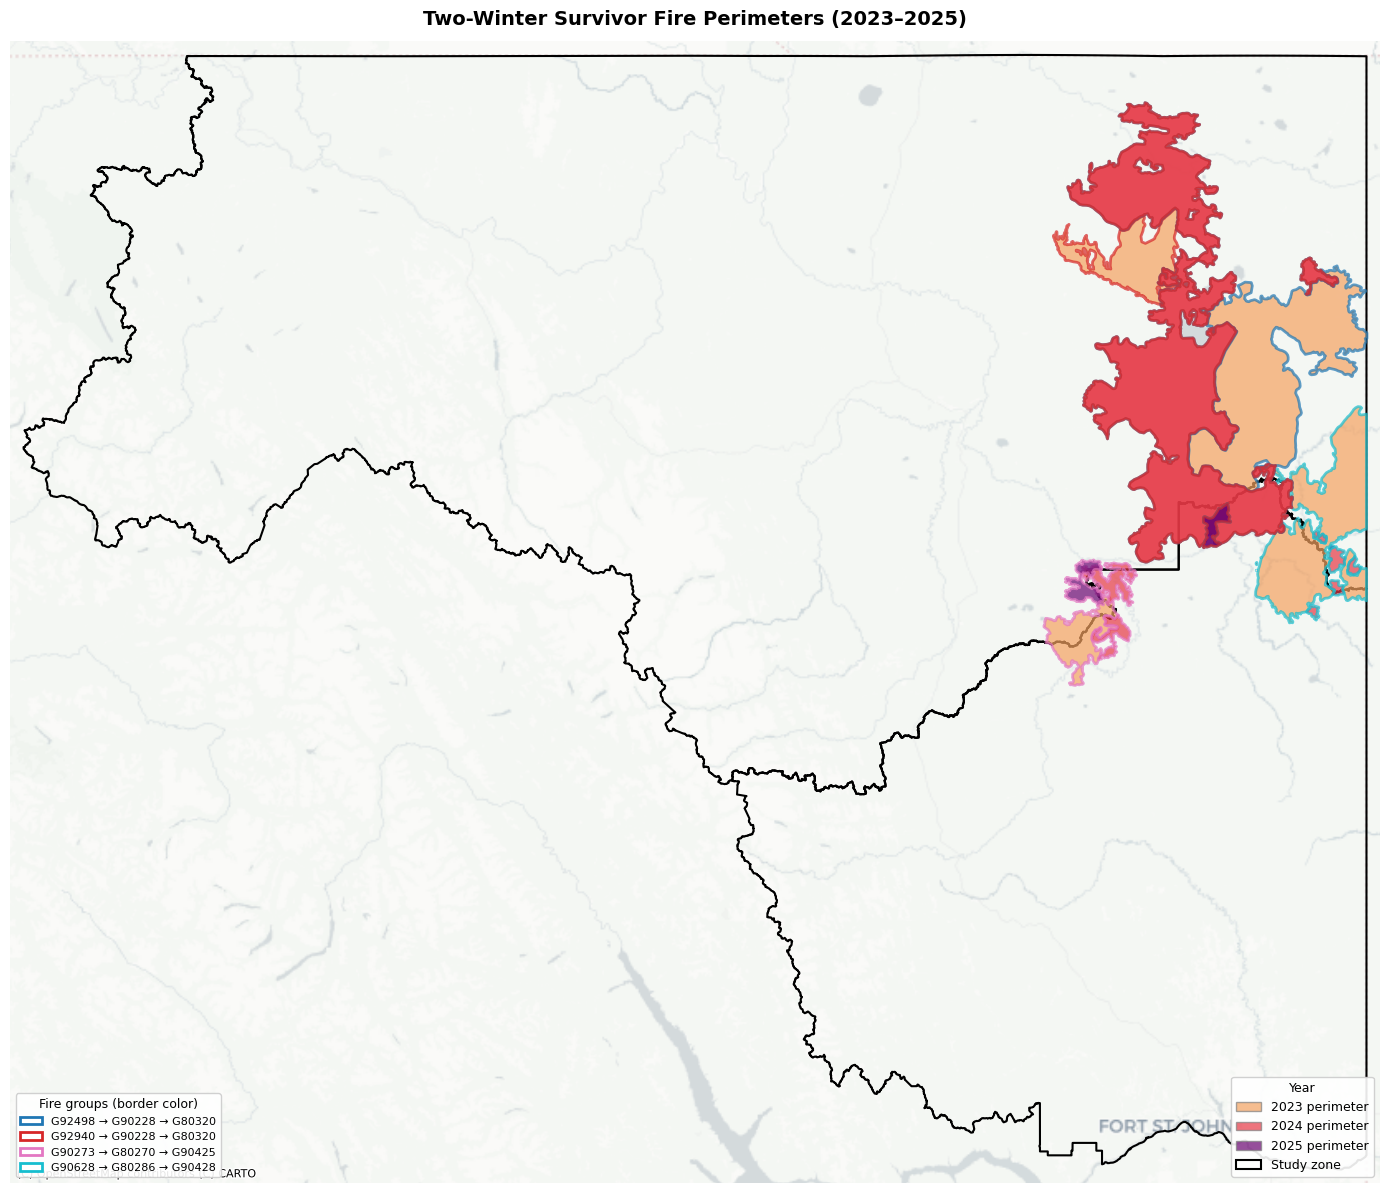

Map saved: two_winter_survivors_grouped.png


In [84]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
import numpy as np
from matplotlib.colors import to_hex
import matplotlib.cm as cm

# --- Load study zone ---
study_zone = gpd.read_file('../data/processed_study_zones/study_zones_3005.geojson').to_crs(epsg=3857)

# --- Assign a unique border color per fire group ---

n_fires = len(two_winter_confirmed_filtered)
cmap = cm.get_cmap('tab10', n_fires) if n_fires <= 10 else cm.get_cmap('tab20', n_fires)
group_border_colors = {
    row['FIRE_NO_2023']: to_hex(cmap(i))
    for i, (_, row) in enumerate(two_winter_confirmed_filtered.iterrows())
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 12))

# Study zone outline
study_zone.plot(ax=ax, color='none', edgecolor='black',
                linewidth=1.5, zorder=2)

legend_fire_groups = []

for _, fire in two_winter_confirmed_filtered.iterrows():
    fn_2023      = fire['FIRE_NO_2023']
    fn_2024      = fire['FIRE_NO_2024']
    fn_2025      = fire['FIRE_NO_2025']
    border_color = group_border_colors[fn_2023]

    perim_23 = perimeters_2023[perimeters_2023['FIRE_NO'] == fn_2023].to_crs(epsg=3857)
    perim_24 = perimeters_2024[perimeters_2024['FIRE_NO'] == fn_2024].to_crs(epsg=3857)
    perim_25 = perimeters_2025[perimeters_2025['FIRE_NO'] == fn_2025].to_crs(epsg=3857)

    # Fill — same colours as before, unique border per group
    if not perim_23.empty:
        perim_23.plot(ax=ax, color='#f4a261', alpha=0.7,
                      edgecolor=border_color, linewidth=2, zorder=3)
    if not perim_24.empty:
        perim_24.plot(ax=ax, color='#e63946', alpha=0.7,
                      edgecolor=border_color, linewidth=2, zorder=4)
    if not perim_25.empty:
        perim_25.plot(ax=ax, color='#6a0572', alpha=0.7,
                      edgecolor=border_color, linewidth=2, zorder=5)

    legend_fire_groups.append(
        mpatches.Patch(facecolor='white', edgecolor=border_color,
                       linewidth=2, label=f'{fn_2023} → {fn_2024} → {fn_2025}')
    )

# --- Legend ---
year_legend = [
    mpatches.Patch(facecolor='#f4a261', edgecolor='grey', alpha=0.7, label='2023 perimeter'),
    mpatches.Patch(facecolor='#e63946', edgecolor='grey', alpha=0.7, label='2024 perimeter'),
    mpatches.Patch(facecolor='#6a0572', edgecolor='grey', alpha=0.7, label='2025 perimeter'),
    mpatches.Patch(facecolor='none',    edgecolor='black', linewidth=1.5, label='Study zone'),
]

# Two separate legends — one for year colors, one for fire groups
legend1 = ax.legend(handles=year_legend, loc='lower right',
                    fontsize=9, framealpha=0.9,
                    title='Year', title_fontsize=9)
ax.add_artist(legend1)

legend2 = ax.legend(handles=legend_fire_groups, loc='lower left',
                    fontsize=8, framealpha=0.9,
                    title='Fire groups (border color)',
                    title_fontsize=9)

# --- Extent from study zone ---
bounds = study_zone.total_bounds
pad = 10000
ax.set_xlim(bounds[0] - pad, bounds[2] + pad)
ax.set_ylim(bounds[1] - pad, bounds[3] + pad)

# --- Basemap ---
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom='auto')

ax.set_title('Two-Winter Survivor Fire Perimeters (2023–2025)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('two_winter_survivors_grouped.png', dpi=300, bbox_inches='tight')
plt.show()
print("Map saved: two_winter_survivors_grouped.png")

In [85]:
# Dictionary of dataframes, one per fire cluster
fire_cluster_dfs = {}

for _, fire in two_winter_confirmed_filtered.iterrows():
    fn_2023 = fire['FIRE_NO_2023']
    fn_2024 = fire['FIRE_NO_2024']
    fn_2025 = fire['FIRE_NO_2025']

    # Subset full_df for this fire
    cluster_df = full_df[full_df['FIRE_NO_2023'] == fn_2023].copy()

    fire_cluster_dfs[fn_2023] = cluster_df

# Sanity check
for fn, df in fire_cluster_dfs.items():
    print(f"{fn} | rows: {len(df)} | "
          f"years: {sorted(df['hotspot_year'].unique())} | "
          f"hs_types: {df['hs_type'].unique().tolist()}")

G92498 | rows: 23499 | years: [np.int32(2023), np.int32(2024), np.int32(2025)] | hs_types: ['within_perimeter', 'within_buffer']
G92940 | rows: 23406 | years: [np.int32(2023), np.int32(2024), np.int32(2025)] | hs_types: ['within_perimeter', 'within_buffer']
G90273 | rows: 3784 | years: [np.int32(2023), np.int32(2024), np.int32(2025)] | hs_types: ['within_perimeter', 'within_buffer']
G90628 | rows: 826 | years: [np.int32(2023), np.int32(2024), np.int32(2025)] | hs_types: ['within_perimeter', 'within_buffer']


Find closest hotspots pair: 
- w1 in_periemter to in_buffer
- w2 inperim tp in_buffer

In [88]:
from shapely.geometry import LineString
import pandas as pd

results = []

for fn_2023, cluster_df in fire_cluster_dfs.items():

    fire_row = two_winter_confirmed_filtered[
        two_winter_confirmed_filtered['FIRE_NO_2023'] == fn_2023
    ].iloc[0]
    fn_2024 = fire_row['FIRE_NO_2024']
    fn_2025 = fire_row['FIRE_NO_2025']

    # ── W1 ────────────────────────────────────────────────────────────────
    w1_perim = cluster_df[
        (cluster_df['winter_year'] == 'W1_2023_2024') &
        (cluster_df['hs_type'] == 'within_perimeter')
    ].copy()

    w1_buf = cluster_df[
        (cluster_df['winter_year'] == 'W1_2023_2024') &
        (cluster_df['hs_type'] == 'within_buffer')
    ].copy()

    # ── W2 ────────────────────────────────────────────────────────────────
    w2_perim = cluster_df[
        (cluster_df['winter_year'] == 'W2_2024_2025') &
        (cluster_df['hs_type'] == 'within_perimeter')
    ].copy()

    w2_buf = cluster_df[
        (cluster_df['winter_year'] == 'W2_2024_2025') &
        (cluster_df['hs_type'] == 'within_buffer')
    ].copy()

    # Skip if any subset is empty
    missing = []
    if w1_perim.empty: missing.append('W1 perimeter')
    if w1_buf.empty:   missing.append('W1 buffer')
    if w2_perim.empty: missing.append('W2 perimeter')
    if w2_buf.empty:   missing.append('W2 buffer')
    if missing:
        print(f"Skipping {fn_2023} — missing: {', '.join(missing)}")
        continue

def find_closest_pair(perim_df, buf_df):
    min_dist   = float('inf')
    best_perim = None
    best_buf   = None

    for _, p_row in perim_df.iterrows():
        dists = buf_df.geometry.distance(p_row.geometry)
        idx   = dists.idxmin()
        dist  = dists[idx]
        if dist < min_dist:
            min_dist   = dist
            best_perim = p_row
            best_buf   = buf_df.loc[idx]

    return best_perim, best_buf, min_dist

results = []

for fn_2023, cluster_df in fire_cluster_dfs.items():

    fire_row = two_winter_confirmed_filtered[
        two_winter_confirmed_filtered['FIRE_NO_2023'] == fn_2023
    ].iloc[0]
    fn_2024 = fire_row['FIRE_NO_2024']
    fn_2025 = fire_row['FIRE_NO_2025']

    # W1 — no date filter needed, 2023 perimeter hotspots are full year
    w1_perim = cluster_df[
        (cluster_df['winter_year'] == 'W1_2023_2024') &
        (cluster_df['hs_type'] == 'within_perimeter')
    ].copy()

    w1_buf = cluster_df[
        (cluster_df['winter_year'] == 'W1_2023_2024') &
        (cluster_df['hs_type'] == 'within_buffer')
    ].copy()

    # W2 perimeter — only Oct, Nov, Dec 2024 (end of fire season)
    w2_perim = cluster_df[
        (cluster_df['winter_year'] == 'W2_2024_2025') &
        (cluster_df['hs_type'] == 'within_perimeter') &
        (cluster_df['date'].dt.month.isin([10, 11, 12]))
    ].copy()

    w2_buf = cluster_df[
        (cluster_df['winter_year'] == 'W2_2024_2025') &
        (cluster_df['hs_type'] == 'within_buffer')
    ].copy()

    # Skip if any subset is empty
    missing = []
    if w1_perim.empty: missing.append('W1 perimeter')
    if w1_buf.empty:   missing.append('W1 buffer')
    if w2_perim.empty: missing.append('W2 perimeter (Oct-Dec)')
    if w2_buf.empty:   missing.append('W2 buffer')
    if missing:
        print(f"Skipping {fn_2023} — missing: {', '.join(missing)}")
        continue

    # Find closest pairs
    w1_p, w1_b, w1_dist = find_closest_pair(w1_perim, w1_buf)
    w2_p, w2_b, w2_dist = find_closest_pair(w2_perim, w2_buf)

    w1_days = (w1_b['date'] - w1_p['date']).days
    w2_days = (w2_b['date'] - w2_p['date']).days

    results.append({
        'FIRE_NO_2023':    fn_2023,
        'FIRE_NO_2024':    fn_2024,
        'FIRE_NO_2025':    fn_2025,

        'w1_perim_date':   w1_p['date'],
        'w1_perim_sat':    w1_p['SATELLITE'],
        'w1_perim_frp':    w1_p['FRP'],
        'w1_perim_x':      w1_p.geometry.x,
        'w1_perim_y':      w1_p.geometry.y,

        'w1_buf_date':     w1_b['date'],
        'w1_buf_sat':      w1_b['SATELLITE'],
        'w1_buf_frp':      w1_b['FRP'],
        'w1_buf_x':        w1_b.geometry.x,
        'w1_buf_y':        w1_b.geometry.y,

        'w1_dist_m':       round(w1_dist, 2),
        'w1_days_between': w1_days,

        'w2_perim_date':   w2_p['date'],
        'w2_perim_sat':    w2_p['SATELLITE'],
        'w2_perim_frp':    w2_p['FRP'],
        'w2_perim_x':      w2_p.geometry.x,
        'w2_perim_y':      w2_p.geometry.y,

        'w2_buf_date':     w2_b['date'],
        'w2_buf_sat':      w2_b['SATELLITE'],
        'w2_buf_frp':      w2_b['FRP'],
        'w2_buf_x':        w2_b.geometry.x,
        'w2_buf_y':        w2_b.geometry.y,

        'w2_dist_m':       round(w2_dist, 2),
        'w2_days_between': w2_days,
    })

closest_pairs_df = pd.DataFrame(results)

print(f"Fires processed: {len(closest_pairs_df)}")
print(closest_pairs_df[[
    'FIRE_NO_2023',
    'w1_perim_date', 'w1_buf_date', 'w1_days_between', 'w1_dist_m',
    'w2_perim_date', 'w2_buf_date', 'w2_days_between', 'w2_dist_m'
]].to_string())

closest_pairs_df.to_csv('overwinter_closest_pairs.csv', index=False)


Skipping G90273 — missing: W2 perimeter (Oct-Dec)
Skipping G90628 — missing: W2 perimeter (Oct-Dec)
Fires processed: 2
  FIRE_NO_2023 w1_perim_date w1_buf_date  w1_days_between  w1_dist_m w2_perim_date w2_buf_date  w2_days_between  w2_dist_m
0       G92498    2023-10-04  2024-04-23              202      30.89    2024-10-09  2025-05-12              215     595.48
1       G92940    2023-10-20  2024-05-13              206     136.48    2024-10-09  2025-05-12              215     595.48


In [89]:
for fn_2023 in ['G90273', 'G90628']:
    cluster_df = fire_cluster_dfs[fn_2023]
    
    w2_perim_all = cluster_df[
        (cluster_df['winter_year'] == 'W2_2024_2025') &
        (cluster_df['hs_type'] == 'within_perimeter')
    ].copy()
    
    print(f"\n{fn_2023} — W2 perimeter hotspots (all months):")
    print(f"  Total: {len(w2_perim_all)}")
    if not w2_perim_all.empty:
        print(f"  Months present: {sorted(w2_perim_all['date'].dt.month.unique())}")
        print(f"  Date range: {w2_perim_all['date'].min().date()} → {w2_perim_all['date'].max().date()}")
        print(w2_perim_all[['date', 'SATELLITE', 'FRP', 'confidence_class']].to_string())
    else:
        print("  No W2 perimeter hotspots at all")


G90273 — W2 perimeter hotspots (all months):
  Total: 3353
  Months present: [np.int32(5), np.int32(6)]
  Date range: 2024-05-09 → 2024-06-01
           date SATELLITE     FRP confidence_class
114  2024-05-09         N    9.00           medium
115  2024-05-09       N20    6.60           medium
116  2024-05-09       N20   49.31           medium
117  2024-05-09      Aqua   42.40             high
118  2024-05-09       N20    6.22           medium
119  2024-05-09       N21    9.55           medium
120  2024-05-09     Terra   30.00             high
121  2024-05-09       N21   10.42           medium
122  2024-05-09      Aqua   53.80             high
123  2024-05-09         N   12.23           medium
124  2024-05-10         N    9.92           medium
125  2024-05-10         N   23.11           medium
126  2024-05-10         N   10.56           medium
127  2024-05-10       N21   52.19             high
128  2024-05-10         N   23.11           medium
129  2024-05-10       N21   52.19        

In [90]:
# The loop completed but output was truncated - view just the G90628 summary
fn_2023 = 'G90628'
cluster_df = fire_cluster_dfs[fn_2023]

w2_perim_all = cluster_df[
    (cluster_df['winter_year'] == 'W2_2024_2025') &
    (cluster_df['hs_type'] == 'within_perimeter')
].copy()

print(f"\n{fn_2023} — W2 perimeter hotspots (all months):")
print(f"  Total: {len(w2_perim_all)}")
if not w2_perim_all.empty:
    print(f"  Months present: {sorted(w2_perim_all['date'].dt.month.unique())}")
    print(f"  Date range: {w2_perim_all['date'].min().date()} → {w2_perim_all['date'].max().date()}")


G90628 — W2 perimeter hotspots (all months):
  Total: 496
  Months present: [np.int32(5), np.int32(6)]
  Date range: 2024-05-10 → 2024-06-01


Fires in closest pairs: 2
<ArrowStringArray>
['G92498', 'G92940']
Length: 2, dtype: str


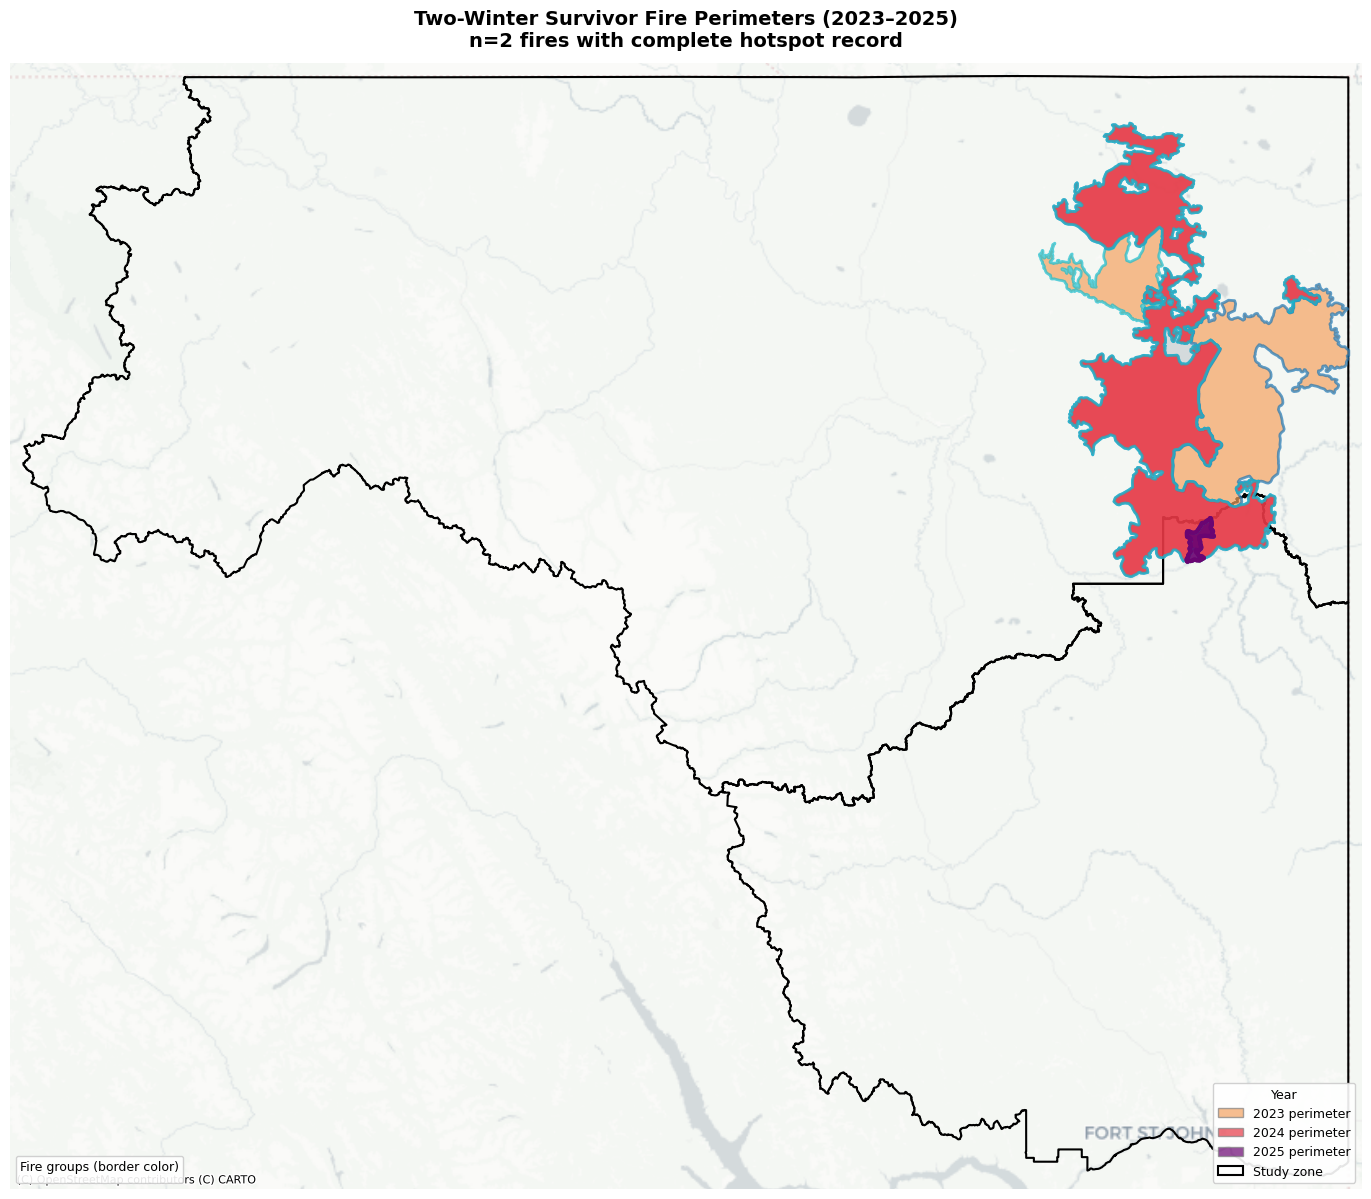

Map saved: two_winter_survivors_closest_pairs.png


In [94]:
# Get fires that were successfully processed in closest_pairs_df
confirmed_cluster_ids = closest_pairs_df['FIRE_NO_2023'].unique()

print(f"Fires in closest pairs: {len(confirmed_cluster_ids)}")
print(confirmed_cluster_ids)

# Filter two_winter_confirmed_filtered to only these fires
two_winter_confirmed_closest = two_winter_confirmed_filtered[
    two_winter_confirmed_filtered['FIRE_NO_2023'].isin(confirmed_cluster_ids)
].copy()

# Reassign border colors for this reduced set
n_fires = len(two_winter_confirmed_closest)
cmap = cm.get_cmap('tab10', n_fires) if n_fires <= 10 else cm.get_cmap('tab20', n_fires)
group_border_colors = {
    row['FIRE_NO_2023']: to_hex(cmap(i))
    for i, (_, row) in enumerate(two_winter_confirmed_closest.iterrows())
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 12))

study_zone.plot(ax=ax, color='none', edgecolor='black',
                linewidth=1.5, zorder=2)

legend_fire_groups = []

for _, fire in two_winter_confirmed_closest.iterrows():
    fn_2023      = fire['FIRE_NO_2023']
    fn_2024      = fire['FIRE_NO_2024']
    fn_2025      = fire['FIRE_NO_2025']
    border_color = group_border_colors[fn_2023]

    perim_23 = perimeters_2023[perimeters_2023['FIRE_NO'] == fn_2023].to_crs(epsg=3857)
    perim_24 = perimeters_2024[perimeters_2024['FIRE_NO'] == fn_2024].to_crs(epsg=3857)
    perim_25 = perimeters_2025[perimeters_2025['FIRE_NO'] == fn_2025].to_crs(epsg=3857)

    # 2023 and 2024 — filled as before
    if not perim_23.empty:
        perim_23.plot(ax=ax, color='#f4a261', alpha=0.7,
                      edgecolor=border_color, linewidth=2, zorder=3)
    if not perim_24.empty:
        perim_24.plot(ax=ax, color='#e63946', alpha=0.7,
                      edgecolor=border_color, linewidth=2, zorder=4)

    # 2025 — NO fill, thick purple outline only so it's always visible on top
    if not perim_25.empty:
        perim_25.plot(ax=ax, color='#6a0572', alpha=0.7,
                      edgecolor=border_color, linewidth=2, zorder=6)
        # Extra purple outline on top of everything
        perim_25.plot(ax=ax, color='none',
                      edgecolor='#6a0572', linewidth=3, zorder=7)

# --- Extent from study zone ---
bounds = study_zone.total_bounds
pad = 10000
ax.set_xlim(bounds[0] - pad, bounds[2] + pad)
ax.set_ylim(bounds[1] - pad, bounds[3] + pad)

# --- Basemap ---
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom='auto')

# --- Two legends ---
year_legend = [
    mpatches.Patch(facecolor='#f4a261', edgecolor='grey', alpha=0.7, label='2023 perimeter'),
    mpatches.Patch(facecolor='#e63946', edgecolor='grey', alpha=0.7, label='2024 perimeter'),
    mpatches.Patch(facecolor='#6a0572', edgecolor='grey', alpha=0.7, label='2025 perimeter'),
    mpatches.Patch(facecolor='none',    edgecolor='black', linewidth=1.5, label='Study zone'),
]

legend1 = ax.legend(handles=year_legend, loc='lower right',
                    fontsize=9, framealpha=0.9,
                    title='Year', title_fontsize=9)
ax.add_artist(legend1)

legend2 = ax.legend(handles=legend_fire_groups, loc='lower left',
                    fontsize=8, framealpha=0.9,
                    title='Fire groups (border color)',
                    title_fontsize=9)

ax.set_title(f'Two-Winter Survivor Fire Perimeters (2023–2025)\n'
             f'n={len(two_winter_confirmed_closest)} fires with complete hotspot record',
             fontsize=14, fontweight='bold', pad=12)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('two_winter_survivors_closest_pairs.png', dpi=300, bbox_inches='tight')
plt.show()
print("Map saved: two_winter_survivors_closest_pairs.png")

In [93]:
for _, fire in two_winter_confirmed_closest.iterrows():
    fn_2023 = fire['FIRE_NO_2023']
    fn_2024 = fire['FIRE_NO_2024']
    fn_2025 = fire['FIRE_NO_2025']

    perim_23 = perimeters_2023[perimeters_2023['FIRE_NO'] == fn_2023]
    perim_24 = perimeters_2024[perimeters_2024['FIRE_NO'] == fn_2024]
    perim_25 = perimeters_2025[perimeters_2025['FIRE_NO'] == fn_2025]

    print(f"\n{fn_2023} → {fn_2024} → {fn_2025}")
    print(f"  2023 perimeter rows: {len(perim_23)} | area: {perim_23.geometry.area.sum():.0f} m²")
    print(f"  2024 perimeter rows: {len(perim_24)} | area: {perim_24.geometry.area.sum():.0f} m²")
    print(f"  2025 perimeter rows: {len(perim_25)} | area: {perim_25.geometry.area.sum():.0f} m²")
    print(f"  2023 bounds: {perim_23.total_bounds.round(0)}")
    print(f"  2024 bounds: {perim_24.total_bounds.round(0)}")
    print(f"  2025 bounds: {perim_25.total_bounds.round(0)}")


G92498 → G90228 → G80320
  2023 perimeter rows: 1 | area: 2750565863 m²
  2024 perimeter rows: 1 | area: 5084734209 m²
  2025 perimeter rows: 1 | area: 75836447 m²
  2023 bounds: [1279027. 1515415. 1344149. 1604048.]
  2024 bounds: [1227194. 1485207. 1331405. 1659531.]
  2025 bounds: [1286683. 1492518. 1297341. 1510269.]

G92940 → G90228 → G80320
  2023 perimeter rows: 1 | area: 710027464 m²
  2024 perimeter rows: 1 | area: 5084734209 m²
  2025 perimeter rows: 1 | area: 75836447 m²
  2023 bounds: [1222644. 1584233. 1272130. 1621084.]
  2024 bounds: [1227194. 1485207. 1331405. 1659531.]
  2025 bounds: [1286683. 1492518. 1297341. 1510269.]


In [95]:
for _, fire in two_winter_confirmed_closest.iterrows():
    fn_2023      = fire['FIRE_NO_2023']
    fn_2024      = fire['FIRE_NO_2024']
    fn_2025      = fire['FIRE_NO_2025']
    border_color = group_border_colors[fn_2023]

    perim_23 = perimeters_2023[perimeters_2023['FIRE_NO'] == fn_2023].to_crs(epsg=3857)
    perim_24 = perimeters_2024[perimeters_2024['FIRE_NO'] == fn_2024].to_crs(epsg=3857)
    perim_25 = perimeters_2025[perimeters_2025['FIRE_NO'] == fn_2025].to_crs(epsg=3857)

    # --- Compute extent from all three perimeters ---
    all_bounds = np.array([
        l.total_bounds for l in [perim_23, perim_24, perim_25]
        if not l.empty
    ])
    pad = 5000
    minx = all_bounds[:, 0].min() - pad
    miny = all_bounds[:, 1].min() - pad
    maxx = all_bounds[:, 2].max() + pad
    maxy = all_bounds[:, 3].max() + pad

    fig, axes = plt.subplots(1, 3, figsize=(18, 8))

    titles    = ['2023 Perimeter', '2024 Perimeter', '2025 Perimeter']
    perims    = [perim_23, perim_24, perim_25]
    colors    = ['#f4a261', '#e63946', '#6a0572']

    for ax, perim, color, title in zip(axes, perims, colors, titles):

        # Plot all three perimeters as context in grey
        for p, c in zip(perims, colors):
            if not p.empty:
                p.plot(ax=ax, color=c, alpha=0.2,
                       edgecolor='grey', linewidth=0.8, zorder=2)

        # Highlight the focal perimeter for this panel
        if not perim.empty:
            perim.plot(ax=ax, color=color, alpha=0.8,
                       edgecolor=border_color, linewidth=2.5, zorder=3)
            # Extra outline for 2025 since it's small
            if color == '#6a0572':
                perim.plot(ax=ax, color='none',
                           edgecolor=color, linewidth=3.5, zorder=4)

        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom='auto')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_axis_off()

    # --- Legend ---
    year_legend = [
        mpatches.Patch(facecolor='#f4a261', edgecolor='grey', alpha=0.8, label='2023 perimeter'),
        mpatches.Patch(facecolor='#e63946', edgecolor='grey', alpha=0.8, label='2024 perimeter'),
        mpatches.Patch(facecolor='#6a0572', edgecolor='grey', alpha=0.8, label='2025 perimeter'),
    ]
    axes[-1].legend(handles=year_legend, loc='lower right',
                    fontsize=8, framealpha=0.9)

    fig.suptitle(f'Fire Cluster: {fn_2023} → {fn_2024} → {fn_2025}',
                 fontsize=13, fontweight='bold', y=1.01)

    plt.tight_layout()
    fname = map_dir / f"{fn_2023}_cluster_panels.png"
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.close()
    print(f"Saved: {fname}")

Saved: ../results/fire_hotspot_maps/G92498_cluster_panels.png
Saved: ../results/fire_hotspot_maps/G92940_cluster_panels.png


DOuble check 2023 hotspots

In [28]:
j1v_c2 =gpd.read_file("../data/raw/2023-24_Hotspots/DL_FIRE_J1V-C2_666396/fire_archive_J1V-C2_666396.shp")

j1v_c2.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry
0,45.02904,-79.68185,335.56,0.65,0.73,2023-10-01,1654,N20,VIIRS,n,2,285.14,5.60,D,0,POINT (-79.68185 45.02904)
1,45.02495,-79.67978,328.84,0.65,0.73,2023-10-01,1654,N20,VIIRS,n,2,285.03,7.52,D,0,POINT (-79.67978 45.02495)
2,51.00452,-78.61643,352.09,0.37,0.58,2023-10-01,1656,N20,VIIRS,n,2,300.03,15.12,D,0,POINT (-78.61643 51.00452)
3,51.00306,-78.62123,367.00,0.37,0.58,2023-10-01,1656,N20,VIIRS,h,2,295.55,15.12,D,0,POINT (-78.62123 51.00306)
4,51.00598,-78.61163,367.00,0.37,0.58,2023-10-01,1656,N20,VIIRS,h,2,293.90,20.33,D,0,POINT (-78.61163 51.00598)


Visualize sdd

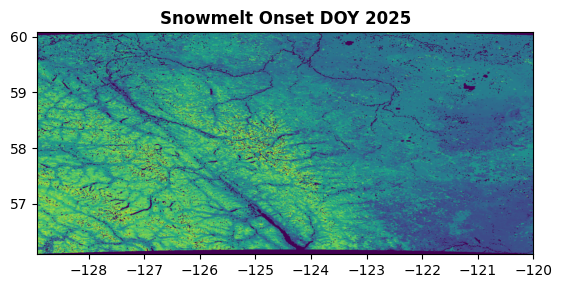

In [2]:
# read in tif file and visualize within zone data/snow_dd/snowmelt_onset_doy_2024.tif
import rasterio
from rasterio.plot import show
tif_path = "../data/snow_dd/SDD_2024.tif"
with rasterio.open(tif_path) as src:
    snowmelt_onset = src.read(1)
    show(src, title="Snowmelt Onset DOY 2025")




In [5]:
# for each 2024 fire perimeter, find the snow melt days within the perimeter and calculate the average
# for each 2024 fire perimeter, find the snow melt days within the perimeter and calculate the average
perimeters_2024 = gpd.read_file("../data/processed_fire_perimeters/perims_2024_clipped_3005.geojson").to_crs(epsg=4326)
perimeters_2024.head()

from rasterio.mask import mask as rio_mask
from shapely.geometry import mapping

def calculate_avg_snowmelt_onset(perim, raster_path):
    with rasterio.open(raster_path) as src:
        geom = mapping(perim.geometry)
        out_image, out_transform = rio_mask(src, [geom], crop=True)
        out_image = out_image[0]

        nodata = src.nodata
        if nodata is None:
            valid_values = out_image[out_image != 0]
        else:
            valid_values = out_image[out_image != nodata]

        if valid_values.size > 0:
            return float(valid_values.mean())
        else:
            return None

perimeters_2024['avg_snowmelt_onset'] = perimeters_2024.apply(
    lambda row: calculate_avg_snowmelt_onset(row, tif_path), axis=1
)

In [6]:
import geopandas as gpd
# do get the average for the study zone as well
study_zone = gpd.read_file('../data/processed_study_zones/study_zones_wgs.geojson')
study_zone['avg_snowmelt_onset'] = study_zone.apply(
    lambda row: calculate_avg_snowmelt_onset(row, tif_path), axis=1
)

In [11]:
#Now for 2025
tif_path2 = "../data/snow_dd/SDD_2025.tif"
study_zone['avg_snowmelt_onset'] = study_zone.apply(
    lambda row: calculate_avg_snowmelt_onset(row, tif_path2), axis=1
)
